<a href="https://colab.research.google.com/github/c0672004-cmd/Customer-Retention-Insights-Python/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# This reads the file straight from your uploaded folder in the left sidebar
path = "/content/Customer Churn.csv"
df = pd.read_csv(path)


In [2]:
# View the first 5 rows and available columns
print("Dataset Sample:")
print(df.head())
print("\nDataset Columns:")
print(df.columns)

Dataset Sample:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies     

In [3]:
# Convert Churn column to standard format if needed (e.g., Yes/No to 1/0)
if df['Churn'].dtype == 'object':
    df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
else:
    df['Churn_Numeric'] = df['Churn']

# Clean TotalCharges if it is stored as text strings
if 'TotalCharges' in df.columns and df['TotalCharges'].dtype == 'object':
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("Data cleaning complete.")


Data cleaning complete.


/tmp/ipykernel_2774/3473878556.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# --- TASK 1: Overall Churn Percentage ---
overall_churn_pct = df['Churn_Numeric'].mean() * 100
print(f"TASK 1: Overall Customer Churn Percentage: {overall_churn_pct:.2f}%\n")

TASK 1: Overall Customer Churn Percentage: 26.54%



In [5]:
# --- TASK 2: Churn Rate by Contract Type ---
if 'Contract' in df.columns:
    contract_churn = df.groupby('Contract')['Churn_Numeric'].mean() * 100
    print("TASK 2: Churn Rate by Contract Type:")

    # Clean version using .map() to format the strings
    print(contract_churn.map(lambda x: f"{x:.2f}%").to_string())
    print("\n")
    print(f"Highest Churn Contract: {contract_churn.idxmax()} ({contract_churn.max():.2f}%)")
    print(f"Lowest Churn Contract: {contract_churn.idxmin()} ({contract_churn.min():.2f}%)")

TASK 2: Churn Rate by Contract Type:
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%


Highest Churn Contract: Month-to-month (42.71%)
Lowest Churn Contract: Two year (2.83%)


In [6]:
# --- TASK 3: Churn Rate by Payment Method ---
if 'PaymentMethod' in df.columns:
    payment_churn = df.groupby('PaymentMethod')['Churn_Numeric'].mean() * 100
    print("TASK 3: Churn Rate by Payment Method:")

    # Clean version using .map() to format the strings
    print(payment_churn.map(lambda x: f"{x:.2f}%").to_string())
    print("\n")
    print(f"Highest Churn Payment Method: {payment_churn.idxmax()} ({payment_churn.max():.2f}%)")

TASK 3: Churn Rate by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.71%
Credit card (automatic)      15.24%
Electronic check             45.29%
Mailed check                 19.11%


Highest Churn Payment Method: Electronic check (45.29%)


In [7]:
# --- TASK 4: Risk Across Demographic Groups ---
# Assumes demographic columns like 'SeniorCitizen', 'Partner', 'Dependents', or 'Gender'
print("TASK 4: Demographic Group Risk Analysis:")
demo_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'Gender']
for col in demo_cols:
    if col in df.columns:
        demo_churn = df.groupby(col)['Churn_Numeric'].mean() * 100
        print(f"\nChurn breakdown by {col}:")
        print(demo_churn.map(lambda x: f"{x:.2f}%").to_string())


TASK 4: Demographic Group Risk Analysis:

Churn breakdown by SeniorCitizen:
SeniorCitizen
0    23.61%
1    41.68%

Churn breakdown by Partner:
Partner
No     32.96%
Yes    19.66%

Churn breakdown by Dependents:
Dependents
No     31.28%
Yes    15.45%


/tmp/ipykernel_2774/4242153648.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Contract', y='Churn_Numeric', data=contract_data, palette='Blues_r')


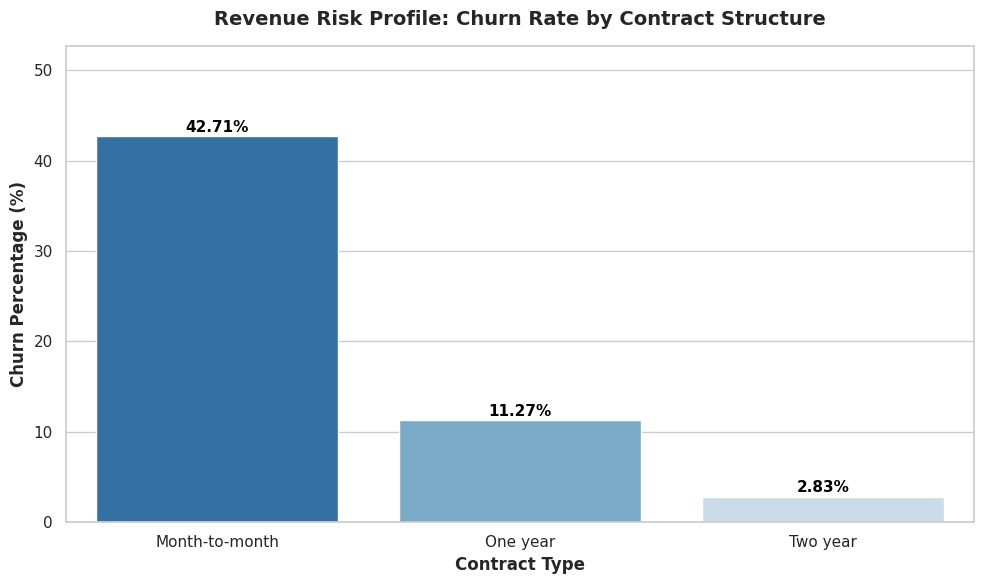

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional financial plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# --- CHART 1: Churn Rate by Contract Structure ---
if 'Contract' in df.columns:
    plt.figure()
    # Calculate group averages
    contract_data = df.groupby('Contract')['Churn_Numeric'].mean().reset_index()
    contract_data['Churn_Numeric'] *= 100 # Convert to percentage

    # Plot bars
    ax = sns.barplot(x='Contract', y='Churn_Numeric', data=contract_data, palette='Blues_r')

    # Titles and labels
    plt.title('Revenue Risk Profile: Churn Rate by Contract Structure', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Contract Type', fontsize=12, fontweight='bold')
    plt.ylabel('Churn Percentage (%)', fontsize=12, fontweight='bold')
    plt.ylim(0, max(contract_data['Churn_Numeric']) + 10) # Add headroom for labels

    # Add data value labels on top of each bar
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                    ha='center', va='center', fontsize=11, color='black', fontweight='bold')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2774/1120522494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn_Numeric', y='PaymentMethod', data=payment_data, palette='Reds_r')


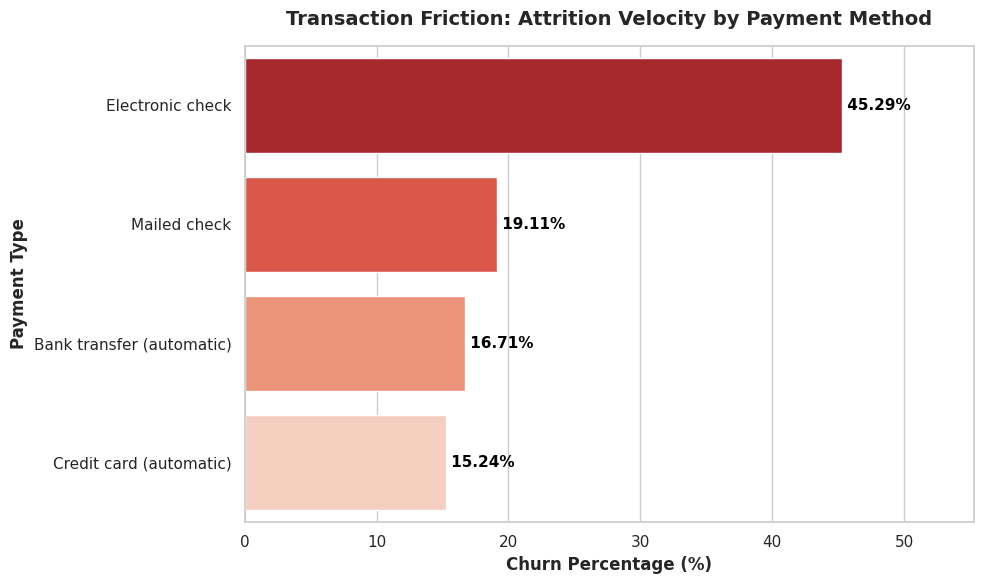

In [10]:
# --- CHART 2: Attrition Velocity by Payment Method ---
if 'PaymentMethod' in df.columns:
    plt.figure()
    payment_data = df.groupby('PaymentMethod')['Churn_Numeric'].mean().reset_index()
    payment_data['Churn_Numeric'] *= 100
    payment_data = payment_data.sort_values(by='Churn_Numeric', ascending=False)

    # Plot horizontal bars for easier text reading
    ax = sns.barplot(x='Churn_Numeric', y='PaymentMethod', data=payment_data, palette='Reds_r')

    plt.title('Transaction Friction: Attrition Velocity by Payment Method', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Churn Percentage (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Payment Type', fontsize=12, fontweight='bold')
    plt.xlim(0, max(payment_data['Churn_Numeric']) + 10)

    # Add labels to horizontal bars
    for p in ax.patches:
        ax.annotate(f" {p.get_width():.2f}%", (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2774/3944459460.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn_Numeric', y='PaymentMethod', data=payment_data, palette='Oranges_r')


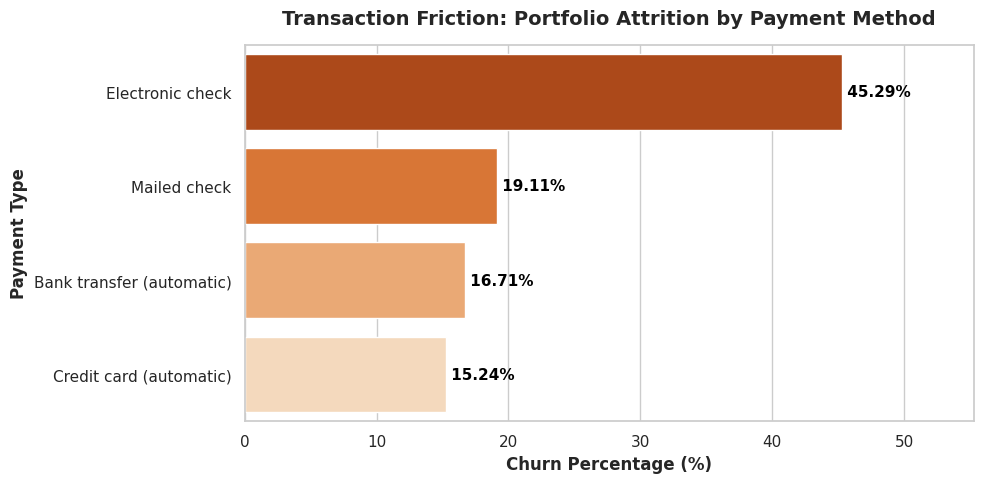

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure professional financial theme settings are active
sns.set_theme(style="whitegrid")

# --- CHART 3: Transaction Friction by Payment Method (Task 3) ---
if 'PaymentMethod' in df.columns:
    plt.figure(figsize=(10, 5))
    payment_data = df.groupby('PaymentMethod')['Churn_Numeric'].mean().reset_index()
    payment_data['Churn_Numeric'] *= 100
    payment_data = payment_data.sort_values(by='Churn_Numeric', ascending=False)

    # Horizontal layout allows long payment method names to be read clearly
    ax = sns.barplot(x='Churn_Numeric', y='PaymentMethod', data=payment_data, palette='Oranges_r')

    plt.title('Transaction Friction: Portfolio Attrition by Payment Method', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Churn Percentage (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Payment Type', fontsize=12, fontweight='bold')
    plt.xlim(0, max(payment_data['Churn_Numeric']) + 10)

    # Add numerical labels onto the horizontal bars
    for p in ax.patches:
        ax.annotate(f" {p.get_width():.2f}%", (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2774/1380926596.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Churn Rate (%)', y='Demographic Cohort', data=demo_df, palette='vlag')


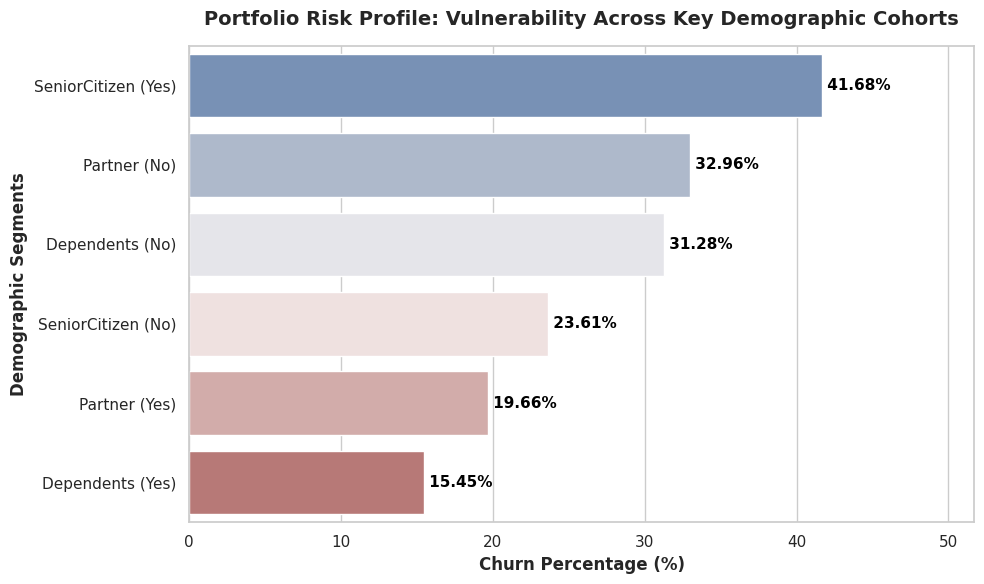

In [12]:
# --- CHART 4: Demographic Risk Profile Matrix (Task 4) ---
# Consolidating demographic flags to look at portfolio risk concentrations
demo_features = ['SeniorCitizen', 'Partner', 'Dependents']
demo_summary = []

for feature in demo_features:
    if feature in df.columns:
        # Group data by feature and map out the differences
        grouped = df.groupby(feature)['Churn_Numeric'].mean() * 100
        for index, val in grouped.items():
            # Standardize labels for financial reporting
            label = "Yes" if index == 1 or str(index).strip().lower() == 'yes' else "No"
            demo_summary.append({'Demographic Cohort': f"{feature} ({label})", 'Churn Rate (%)': val})

if demo_summary:
    plt.figure(figsize=(10, 6))
    demo_df = pd.DataFrame(demo_summary).sort_values(by='Churn Rate (%)', ascending=False)

    ax = sns.barplot(x='Churn Rate (%)', y='Demographic Cohort', data=demo_df, palette='vlag')
    plt.title('Portfolio Risk Profile: Vulnerability Across Key Demographic Cohorts', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Churn Percentage (%)', fontsize=12, fontweight='bold')
    plt.ylabel('Demographic Segments', fontsize=12, fontweight='bold')
    plt.xlim(0, max(demo_df['Churn Rate (%)']) + 10)

    for p in ax.patches:
        ax.annotate(f" {p.get_width():.2f}%", (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')
    plt.tight_layout()
    plt.show()
